Slope = -0.2049 µm²/s
Diffusion constant D = -0.0512 µm²/s
R² of fit = 0.9037


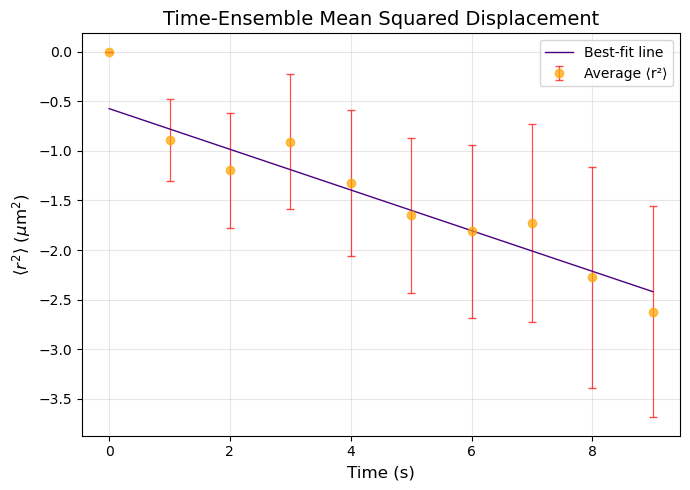

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# -----------------------------
# Load data
# -----------------------------
data = pd.read_csv("Time Ensemble - S4V1.csv")
data = data.sort_values("Slice").reset_index(drop=True)

# -----------------------------
# Parameters
# -----------------------------
num_frames = 600
bin_size = 10
num_bins = num_frames // bin_size  # 60 bins


# -----------------------------
# Calculate r^2 for each bin
# -----------------------------
r2_matrix = np.zeros((num_bins, bin_size))

for i in range(num_bins):
    start = i * bin_size
    end = start + bin_size
    bin_data = data.iloc[start:end]

    # Reference position
    x0, y0 = bin_data.iloc[0][["X", "Y"]]
    dx = bin_data["X"] - x0
    dy = bin_data["Y"] - y0
    r2 = (dx*2 + dy*2)  # convert to µm²
    r2_matrix[i, :] = r2.values

# -----------------------------
# Average <r²> and standard deviation for error bars
# -----------------------------
avg_r2 = r2_matrix.mean(axis=0)
std_r2 = r2_matrix.std(axis=0)
stderr_r2 = std_r2 / np.sqrt(num_bins)  # standard error of mean

# -----------------------------
# Time axis (1 frame = 1 second)
# -----------------------------
time = np.arange(bin_size)  # seconds

# -----------------------------
# Linear regression (diffusive regime)
# -----------------------------
# You can tune how many points you fit — usually early times only
fit_range = slice(1, 10)  # skip t=0, fit over t=1..9

slope, intercept, r_value, p_value, std_err = linregress(time[fit_range], avg_r2[fit_range])
D = slope / 4  # for 2D diffusion

print(f"Slope = {slope:.4f} µm²/s")
print(f"Diffusion constant D = {D:.4f} µm²/s")
print(f"R² of fit = {r_value**2:.4f}")

# -----------------------------
# Best-fit line for plotting
# -----------------------------
fit_line = slope * time + intercept

# -----------------------------
# Plotting
# -----------------------------
plt.figure(figsize=(7,5))
plt.errorbar(
    time, avg_r2, yerr=stderr_r2, fmt='o', 
    color='orange', ecolor='red', elinewidth=0.9, capsize=3, 
    markersize=6, alpha=0.7, label='Average ⟨r²⟩'
)
plt.plot(time, fit_line, color='indigo', linewidth=1, label='Best-fit line')

plt.xlabel("Time (s)", fontsize=12)
plt.ylabel(r"$\langle r^2 \rangle$ ($\mu$m$^2$)", fontsize=12)
plt.title("Time-Ensemble Mean Squared Displacement", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()